In [224]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler , LabelEncoder,RobustScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, classification_report,
silhouette_score,confusion_matrix, ConfusionMatrixDisplay,precision_score, recall_score, f1_score,roc_auc_score,log_loss, brier_score_loss,roc_curve, auc )
from sklearn.model_selection import train_test_split , RandomizedSearchCV,StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import os
import warnings
from sklearn.preprocessing import label_binarize
from sklearn.compose import ColumnTransformer
import pickle



In [225]:
os.listdir('archive')

['az_cybersecurity_real_logic.csv',
 'az_ecommerce_100k_clean.csv',
 'bank_clustered.csv',
 'bank_musteri_seqmentasiya.csv',
 'ev_qiymetleri.csv',
 'heart_disease_15k.csv']

In [226]:
df = pd.read_csv('archive/bank_musteri_seqmentasiya.csv')

In [227]:
df.head(n=7)

,yaş,şəhər,peşə,təhsil,ailə_vəziyyəti,maaş_azn,balans_azn,depozit_azn,kredit_balı,kredit_borcu_azn,...,aylıq_əməliyyat_sayı,aylıq_xərc_azn,onlayn_əməliyyat_faizi,gecikmiş_ödəniş_sayı,kart_sayı,sığorta_sayı,bank_məhsulları,churn_riski,cluster,cluster_adı
0,50,Bakı,Hüquqşünas,Magistr,Boşanmış,2821.0,27247.70,5000.00,792,508.79,...,51,1145.82,56.3,0,4,2,Əmanət+Kredit,0.000,0,Premium Müştəri
1,54,Şirvan,Mühəndis,Doktorantura,Dul,2696.0,24039.42,5154.18,785,1886.37,...,47,1442.76,77.5,0,3,1,Əmanət+Kredit+Sığorta+İnvestisiya,0.152,0,Premium Müştəri
2,38,Mingəçevir,Sahibkar,Magistr,Dul,2794.0,22655.47,5354.45,731,1120.64,...,56,1272.55,76.1,0,4,1,Əmanət+Kredit+Sığorta+İnvestisiya,0.058,0,Premium Müştəri
3,60,Bakı,Müdir,Bakalavr,Boşanmış,2500.0,26111.15,5000.00,752,16.61,...,48,1546.76,78.3,1,2,3,Əmanət+Sığorta,0.093,0,Premium Müştəri
4,56,Sumqayıt,Direktor,Magistr,Evli,4882.0,42850.67,5000.00,712,1448.30,...,51,2327.84,62.7,0,2,3,Əmanət+Sığorta,0.271,0,Premium Müştəri
5,51,Naxçıvan,Direktor,Doktorantura,Evli,2500.0,11911.45,5159.21,747,7964.85,...,48,1653.60,82.4,1,3,3,Əmanət+Kredit+Sığorta,0.245,0,Premium Müştəri
6,43,Bakı,Mühəndis,Magistr,Dul,2500.0,25032.71,5000.00,793,753.50,...,32,1707.18,68.2,0,2,4,Əmanət+Kredit+Sığorta,0.122,0,Premium Müştəri


In [228]:
df.columns

Index(['yaş', 'şəhər', 'peşə', 'təhsil', 'ailə_vəziyyəti', 'maaş_azn',
       'balans_azn', 'depozit_azn', 'kredit_balı', 'kredit_borcu_azn',
       'borc_gəlir_nisbəti', 'bank_stajı_il', 'aylıq_əməliyyat_sayı',
       'aylıq_xərc_azn', 'onlayn_əməliyyat_faizi', 'gecikmiş_ödəniş_sayı',
       'kart_sayı', 'sığorta_sayı', 'bank_məhsulları', 'churn_riski',
       'cluster', 'cluster_adı'],
      dtype='object')

In [229]:
df.nunique()

yaş                          48
şəhər                        10
peşə                         28
təhsil                        5
ailə_vəziyyəti                4
maaş_azn                   5828
balans_azn                67208
depozit_azn               26591
kredit_balı                 551
kredit_borcu_azn          64169
borc_gəlir_nisbəti         1500
bank_stajı_il                31
aylıq_əməliyyat_sayı         80
aylıq_xərc_azn            57330
onlayn_əməliyyat_faizi      951
gecikmiş_ödəniş_sayı         15
kart_sayı                     5
sığorta_sayı                  5
bank_məhsulları              11
churn_riski                 778
cluster                       4
cluster_adı                   4
dtype: int64

In [230]:
df.values

array([[50, 'Bakı', 'Hüquqşünas', ..., 0.0, 0, 'Premium Müştəri'],
       [54, 'Şirvan', 'Mühəndis', ..., 0.152, 0, 'Premium Müştəri'],
       [38, 'Mingəçevir', 'Sahibkar', ..., 0.058, 0, 'Premium Müştəri'],
       ...,
       [22, 'Lənkəran', 'Freelancer', ..., 0.168, 3,
        'Gənc/Digital Müştəri'],
       [19, 'Mingəçevir', 'IT Mütəxəssisi', ..., 0.349, 3,
        'Gənc/Digital Müştəri'],
       [27, 'Sumqayıt', 'Dizayner', ..., 0.305, 3,
        'Gənc/Digital Müştəri']], shape=(72000, 22), dtype=object)

In [231]:
df.isna().sum()

yaş                       0
şəhər                     0
peşə                      0
təhsil                    0
ailə_vəziyyəti            0
maaş_azn                  0
balans_azn                0
depozit_azn               0
kredit_balı               0
kredit_borcu_azn          0
borc_gəlir_nisbəti        0
bank_stajı_il             0
aylıq_əməliyyat_sayı      0
aylıq_xərc_azn            0
onlayn_əməliyyat_faizi    0
gecikmiş_ödəniş_sayı      0
kart_sayı                 0
sığorta_sayı              0
bank_məhsulları           0
churn_riski               0
cluster                   0
cluster_adı               0
dtype: int64

In [232]:
df.duplicated().sum()

np.int64(0)

In [233]:
df

,yaş,şəhər,peşə,təhsil,ailə_vəziyyəti,maaş_azn,balans_azn,depozit_azn,kredit_balı,kredit_borcu_azn,...,aylıq_əməliyyat_sayı,aylıq_xərc_azn,onlayn_əməliyyat_faizi,gecikmiş_ödəniş_sayı,kart_sayı,sığorta_sayı,bank_məhsulları,churn_riski,cluster,cluster_adı
0,50,Bakı,Hüquqşünas,Magistr,Boşanmış,2821.0,27247.70,5000.00,792,508.79,...,51,1145.82,56.3,0,4,2,Əmanət+Kredit,0.000,0,Premium Müştəri
1,54,Şirvan,Mühəndis,Doktorantura,Dul,2696.0,24039.42,5154.18,785,1886.37,...,47,1442.76,77.5,0,3,1,Əmanət+Kredit+Sığorta+İnvestisiya,0.152,0,Premium Müştəri
2,38,Mingəçevir,Sahibkar,Magistr,Dul,2794.0,22655.47,5354.45,731,1120.64,...,56,1272.55,76.1,0,4,1,Əmanət+Kredit+Sığorta+İnvestisiya,0.058,0,Premium Müştəri
3,60,Bakı,Müdir,Bakalavr,Boşanmış,2500.0,26111.15,5000.00,752,16.61,...,48,1546.76,78.3,1,2,3,Əmanət+Sığorta,0.093,0,Premium Müştəri
4,56,Sumqayıt,Direktor,Magistr,Evli,4882.0,42850.67,5000.00,712,1448.30,...,51,2327.84,62.7,0,2,3,Əmanət+Sığorta,0.271,0,Premium Müştəri
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71995,23,Sabirabad,Proqramçı,Magistr,Subay,800.0,1301.37,0.00,636,642.24,...,25,421.49,78.1,3,3,1,Kart,0.304,3,Gənc/Digital Müştəri
71996,26,Şəki,Dizayner,Orta ixtisas,Boşanmış,1884.0,2242.96,461.58,543,1090.12,...,28,1283.01,90.6,0,2,1,Kart+Əmanət,0.370,3,Gənc/Digital Müştəri
71997,22,Lənkəran,Freelancer,Orta ixtisas,Subay,1796.0,4331.57,1088.13,722,5766.67,...,24,1425.60,84.3,0,1,0,Əmanət+Kart,0.168,3,Gənc/Digital Müştəri
71998,19,Mingəçevir,IT Mütəxəssisi,Bakalavr,Subay,1143.0,1476.80,396.31,639,1382.17,...,49,888.80,98.5,1,3,0,Kart+Əmanət,0.349,3,Gənc/Digital Müştəri


In [234]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72000 entries, 0 to 71999
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   yaş                     72000 non-null  int64  
 1   şəhər                   72000 non-null  object 
 2   peşə                    72000 non-null  object 
 3   təhsil                  72000 non-null  object 
 4   ailə_vəziyyəti          72000 non-null  object 
 5   maaş_azn                72000 non-null  float64
 6   balans_azn              72000 non-null  float64
 7   depozit_azn             72000 non-null  float64
 8   kredit_balı             72000 non-null  int64  
 9   kredit_borcu_azn        72000 non-null  float64
 10  borc_gəlir_nisbəti      72000 non-null  float64
 11  bank_stajı_il           72000 non-null  int64  
 12  aylıq_əməliyyat_sayı    72000 non-null  int64  
 13  aylıq_xərc_azn          72000 non-null  float64
 14  onlayn_əməliyyat_faizi  72000 non-null

In [235]:
df['maaş_azn'] = df['maaş_azn'].astype('int')

In [236]:
df.tail(n=10)

,yaş,şəhər,peşə,təhsil,ailə_vəziyyəti,maaş_azn,balans_azn,depozit_azn,kredit_balı,kredit_borcu_azn,...,aylıq_əməliyyat_sayı,aylıq_xərc_azn,onlayn_əməliyyat_faizi,gecikmiş_ödəniş_sayı,kart_sayı,sığorta_sayı,bank_məhsulları,churn_riski,cluster,cluster_adı
71990,24,Bakı,SMM Mütəxəssisi,Orta ixtisas,Subay,1517,1431.95,718.02,652,1549.59,...,35,1194.58,86.1,0,3,0,Kart,0.234,3,Gənc/Digital Müştəri
71991,27,Gəncə,Data Analitik,Bakalavr,Evli,1259,2665.30,592.46,712,2148.71,...,49,901.47,74.5,0,2,1,Kart+Əmanət,0.218,3,Gənc/Digital Müştəri
71992,26,Şirvan,SMM Mütəxəssisi,Magistr,Evli,1145,711.50,0.00,583,4684.42,...,32,871.17,87.0,2,1,1,Kart,0.405,3,Gənc/Digital Müştəri
71993,28,Şirvan,SMM Mütəxəssisi,Bakalavr,Dul,1286,3767.05,0.00,681,2981.49,...,36,913.41,99.6,1,1,1,Kart,0.291,3,Gənc/Digital Müştəri
71994,30,Quba,Proqramçı,Bakalavr,Evli,1181,3274.48,0.00,627,1208.99,...,52,657.67,87.5,0,3,1,Kart+Əmanət,0.345,3,Gənc/Digital Müştəri
71995,23,Sabirabad,Proqramçı,Magistr,Subay,800,1301.37,0.00,636,642.24,...,25,421.49,78.1,3,3,1,Kart,0.304,3,Gənc/Digital Müştəri
71996,26,Şəki,Dizayner,Orta ixtisas,Boşanmış,1884,2242.96,461.58,543,1090.12,...,28,1283.01,90.6,0,2,1,Kart+Əmanət,0.370,3,Gənc/Digital Müştəri
71997,22,Lənkəran,Freelancer,Orta ixtisas,Subay,1796,4331.57,1088.13,722,5766.67,...,24,1425.60,84.3,0,1,0,Əmanət+Kart,0.168,3,Gənc/Digital Müştəri
71998,19,Mingəçevir,IT Mütəxəssisi,Bakalavr,Subay,1143,1476.80,396.31,639,1382.17,...,49,888.80,98.5,1,3,0,Kart+Əmanət,0.349,3,Gənc/Digital Müştəri
71999,27,Sumqayıt,Dizayner,Orta ixtisas,Evli,1495,1846.58,926.30,635,1084.68,...,34,1060.18,79.8,0,2,1,Kart+Kredit,0.305,3,Gənc/Digital Müştəri


In [237]:
warnings.filterwarnings('ignore')

In [238]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
yaş,72000.0,37.758750,10.474711,18.00,29.0000,37.000,46.0000,65.000
maaş_azn,72000.0,1665.550653,1247.833759,300.00,800.0000,1200.000,2500.0000,14106.000
balans_azn,72000.0,8244.332113,12609.444509,0.00,702.4000,2493.930,9858.8025,80000.000
depozit_azn,72000.0,1868.796170,2882.290583,0.00,0.0000,388.455,5000.0000,31063.340
kredit_balı,72000.0,624.364819,131.746602,300.00,530.0000,636.000,734.0000,850.000
kredit_borcu_azn,72000.0,5082.471700,5618.063786,0.06,1562.6875,3183.080,6668.1375,50000.000
borc_gəlir_nisbəti,72000.0,39.182594,44.475932,0.00,6.7000,21.300,53.3000,150.000
bank_stajı_il,72000.0,6.094458,4.960204,0.00,2.0000,5.000,9.0000,30.000
aylıq_əməliyyat_sayı,72000.0,26.879542,15.212017,1.00,14.0000,26.000,38.0000,80.000
aylıq_xərc_azn,72000.0,1042.833602,663.253199,210.53,590.7200,823.175,1315.7375,8261.770


In [239]:
df.drop(columns=['cluster','cluster_adı'], axis=1 , inplace=True )

In [240]:
df.describe(include='object')

,şəhər,peşə,təhsil,ailə_vəziyyəti,bank_məhsulları
count,72000,72000,72000,72000,72000
unique,10,28,5,4,11
top,Bakı,Mühasib,Bakalavr,Boşanmış,Əmanət+Kredit
freq,22327,2669,26957,18128,13499


In [241]:
df['peşə'].value_counts()

peşə
Mühasib            2669
Həkim              2651
Data Analitik      2640
Qoruqçu            2631
Tələbə             2623
Proqramçı          2598
Startapçı          2597
Aşpaz              2591
Maliyyəçi          2590
Dizayner           2589
Menecer            2582
Müəllim            2574
Sahibkar           2573
Fəhlə              2565
Aqronom            2563
İşsiz              2563
IT Mütəxəssisi     2562
Texnik             2556
Satıcı             2552
Hüquqşünas         2552
Direktor           2549
Mühəndis           2547
Müdir              2538
Əczacı             2528
Memarı             2528
SMM Mütəxəssisi    2525
Freelancer         2489
Sürücü             2475
Name: count, dtype: int64

In [242]:
df

,yaş,şəhər,peşə,təhsil,ailə_vəziyyəti,maaş_azn,balans_azn,depozit_azn,kredit_balı,kredit_borcu_azn,borc_gəlir_nisbəti,bank_stajı_il,aylıq_əməliyyat_sayı,aylıq_xərc_azn,onlayn_əməliyyat_faizi,gecikmiş_ödəniş_sayı,kart_sayı,sığorta_sayı,bank_məhsulları,churn_riski
0,50,Bakı,Hüquqşünas,Magistr,Boşanmış,2821,27247.70,5000.00,792,508.79,1.5,19,51,1145.82,56.3,0,4,2,Əmanət+Kredit,0.000
1,54,Şirvan,Mühəndis,Doktorantura,Dul,2696,24039.42,5154.18,785,1886.37,5.8,11,47,1442.76,77.5,0,3,1,Əmanət+Kredit+Sığorta+İnvestisiya,0.152
2,38,Mingəçevir,Sahibkar,Magistr,Dul,2794,22655.47,5354.45,731,1120.64,3.3,25,56,1272.55,76.1,0,4,1,Əmanət+Kredit+Sığorta+İnvestisiya,0.058
3,60,Bakı,Müdir,Bakalavr,Boşanmış,2500,26111.15,5000.00,752,16.61,0.1,15,48,1546.76,78.3,1,2,3,Əmanət+Sığorta,0.093
4,56,Sumqayıt,Direktor,Magistr,Evli,4882,42850.67,5000.00,712,1448.30,2.5,7,51,2327.84,62.7,0,2,3,Əmanət+Sığorta,0.271
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71995,23,Sabirabad,Proqramçı,Magistr,Subay,800,1301.37,0.00,636,642.24,6.7,1,25,421.49,78.1,3,3,1,Kart,0.304
71996,26,Şəki,Dizayner,Orta ixtisas,Boşanmış,1884,2242.96,461.58,543,1090.12,4.8,1,28,1283.01,90.6,0,2,1,Kart+Əmanət,0.370
71997,22,Lənkəran,Freelancer,Orta ixtisas,Subay,1796,4331.57,1088.13,722,5766.67,26.8,1,24,1425.60,84.3,0,1,0,Əmanət+Kart,0.168
71998,19,Mingəçevir,IT Mütəxəssisi,Bakalavr,Subay,1143,1476.80,396.31,639,1382.17,10.1,1,49,888.80,98.5,1,3,0,Kart+Əmanət,0.349


In [243]:
label_encode = LabelEncoder()
categorical = ['şəhər' , 'peşə' ,'təhsil' ,'ailə_vəziyyəti' , 'bank_məhsulları']
for col in categorical:
    df[col] = label_encode.fit_transform(df[col])

In [244]:
df.head()

,yaş,şəhər,peşə,təhsil,ailə_vəziyyəti,maaş_azn,balans_azn,depozit_azn,kredit_balı,kredit_borcu_azn,borc_gəlir_nisbəti,bank_stajı_il,aylıq_əməliyyat_sayı,aylıq_xərc_azn,onlayn_əməliyyat_faizi,gecikmiş_ödəniş_sayı,kart_sayı,sığorta_sayı,bank_məhsulları,churn_riski
0,50,0,7,2,0,2821,27247.70,5000.00,792,508.79,1.5,19,51,1145.82,56.3,0,4,2,7,0.000
1,54,8,15,1,1,2696,24039.42,5154.18,785,1886.37,5.8,11,47,1442.76,77.5,0,3,1,9,0.152
2,38,3,20,2,1,2794,22655.47,5354.45,731,1120.64,3.3,25,56,1272.55,76.1,0,4,1,9,0.058
3,60,0,13,0,0,2500,26111.15,5000.00,752,16.61,0.1,15,48,1546.76,78.3,1,2,3,10,0.093
4,56,7,3,2,2,4882,42850.67,5000.00,712,1448.30,2.5,7,51,2327.84,62.7,0,2,3,10,0.271


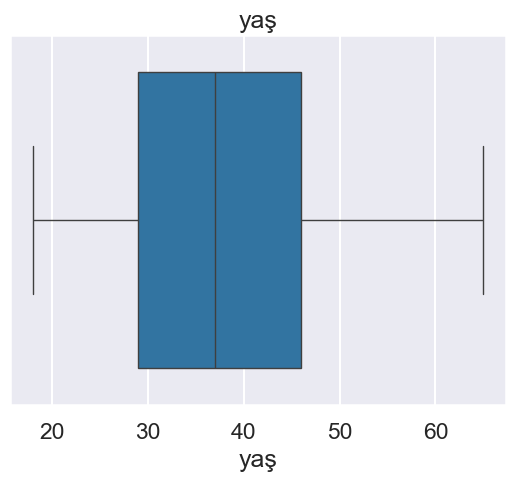

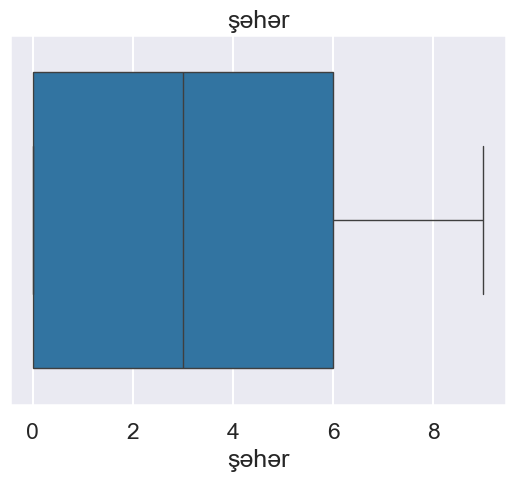

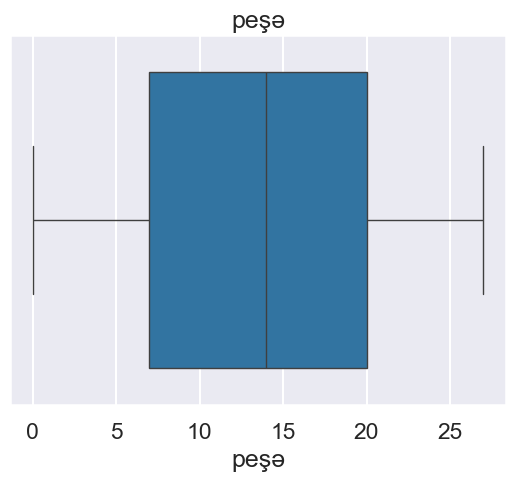

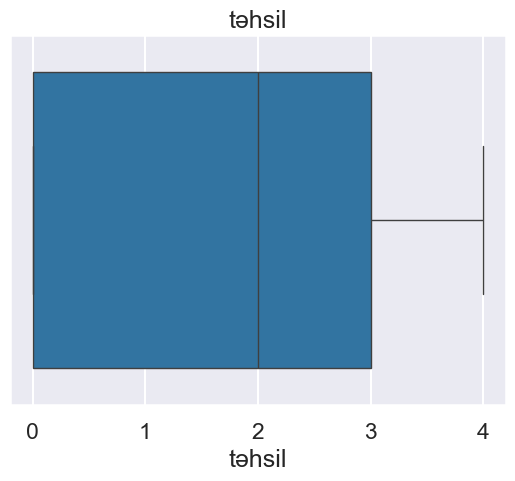

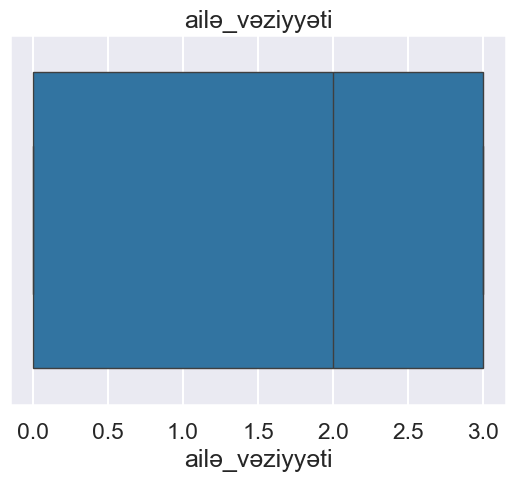

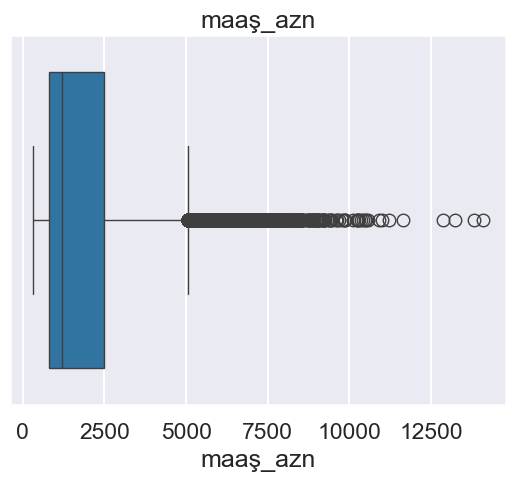

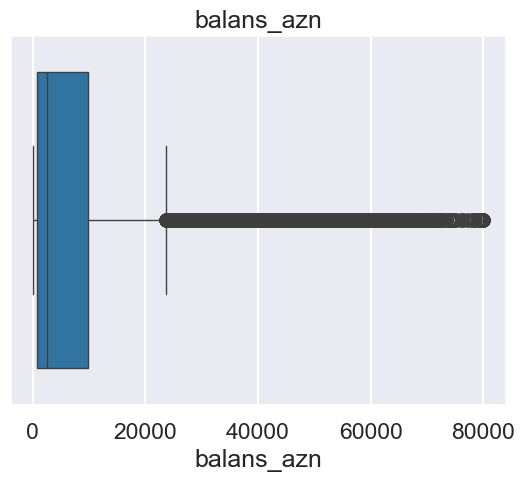

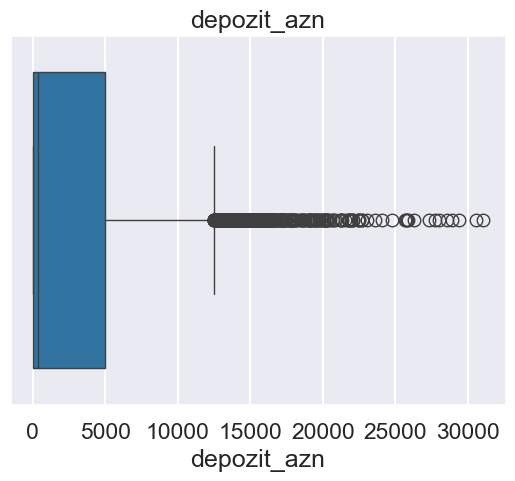

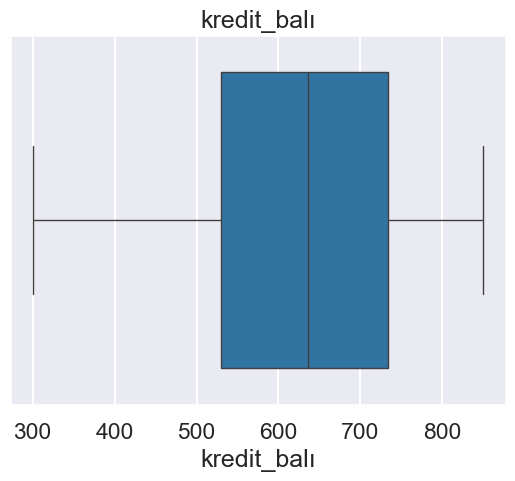

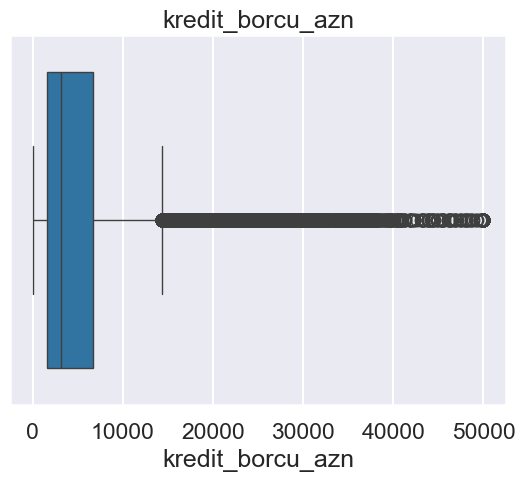

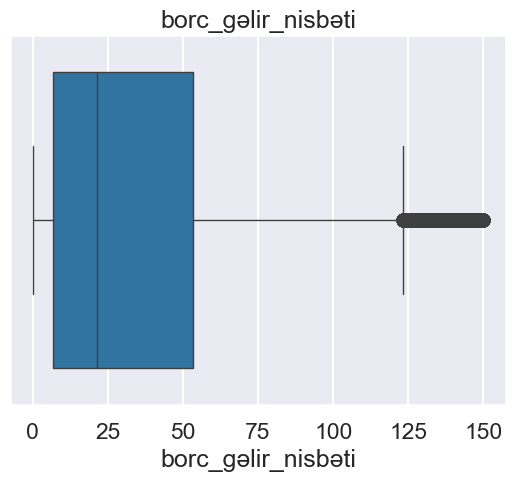

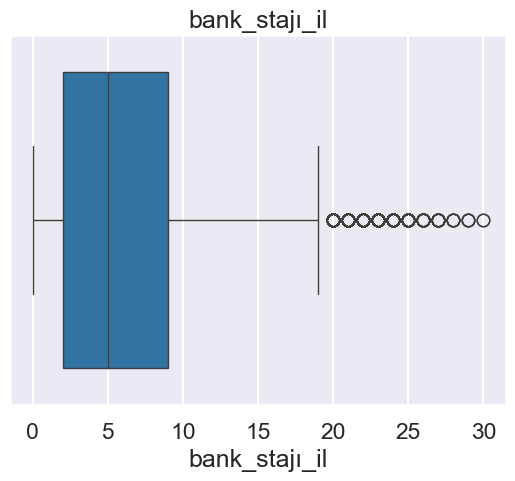

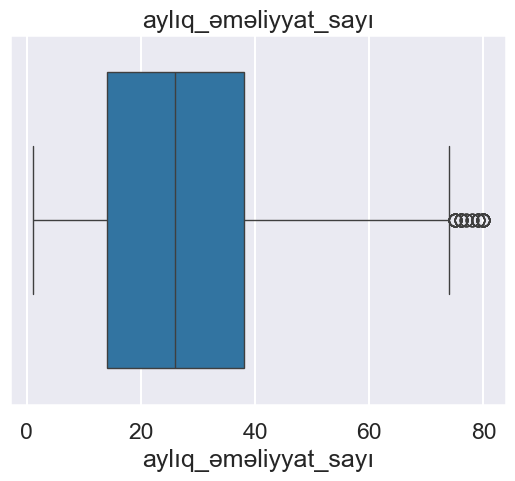

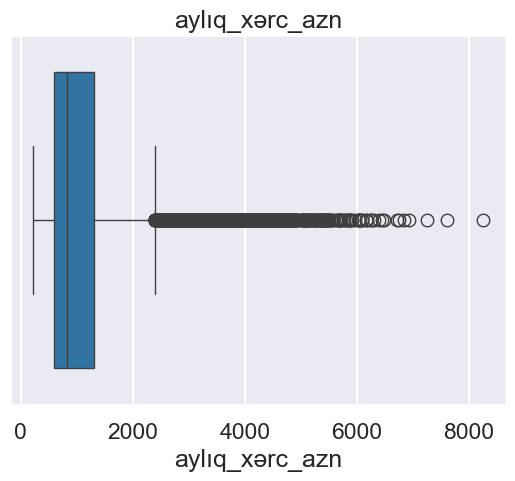

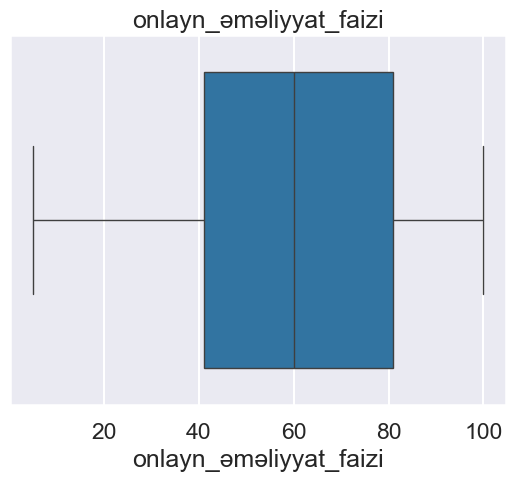

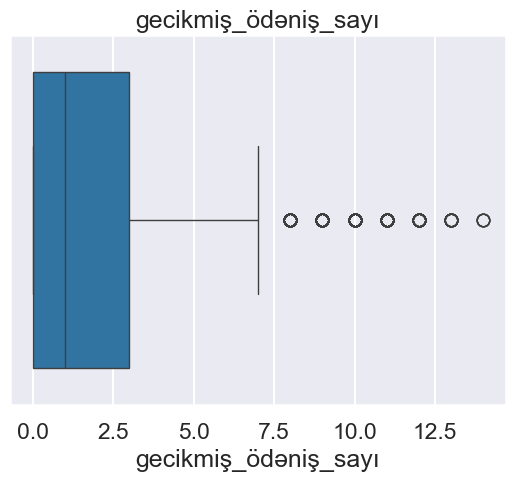

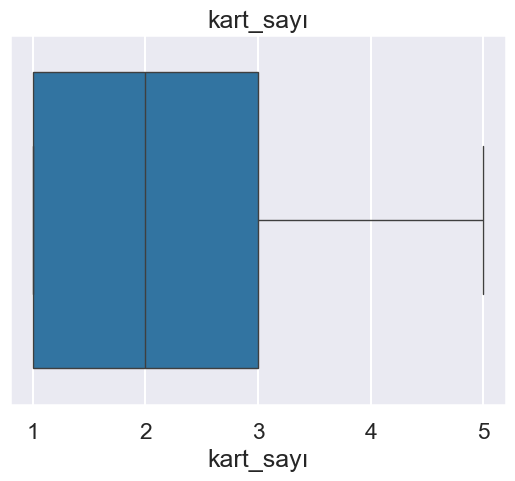

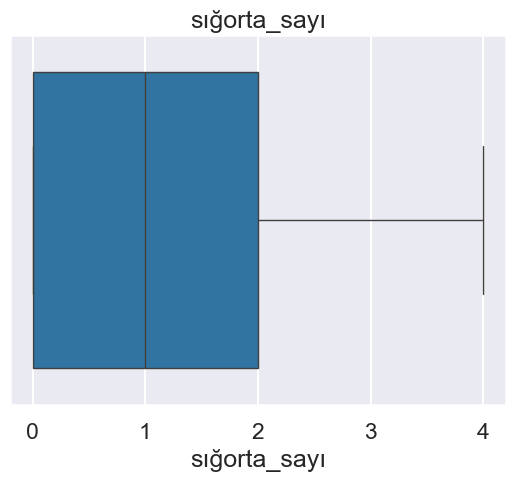

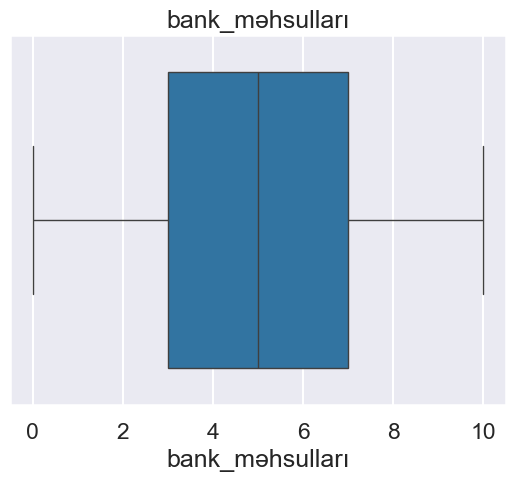

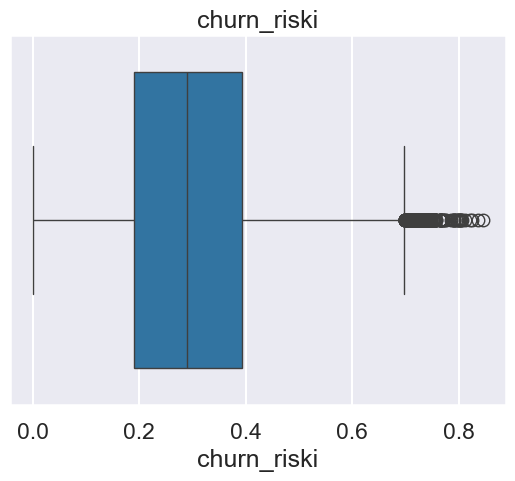

In [245]:
for col in df.select_dtypes(include='number').columns:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [246]:
standart_scale = ['yaş' , 'şəhər' , 'peşə','təhsil' , 'ailə_vəziyyəti' , 'kredit_balı' , 'onlayn_əməliyyat_faizi' ,'kart_sayı' , 'sığorta_sayı' , 'bank_məhsulları']
robust_scale = ['maaş_azn' , 'balans_azn' , 'depozit_azn' ,'kredit_borcu_azn' , 'borc_gəlir_nisbəti' , 'bank_stajı_il' ,'aylıq_əməliyyat_sayı'  , 'aylıq_xərc_azn' , 'gecikmiş_ödəniş_sayı' ,'churn_riski']
ct = ColumnTransformer([
    ('robust' , RobustScaler() , robust_scale),
    ('standart' , StandardScaler() , standart_scale)
])
x = ct.fit_transform(df)

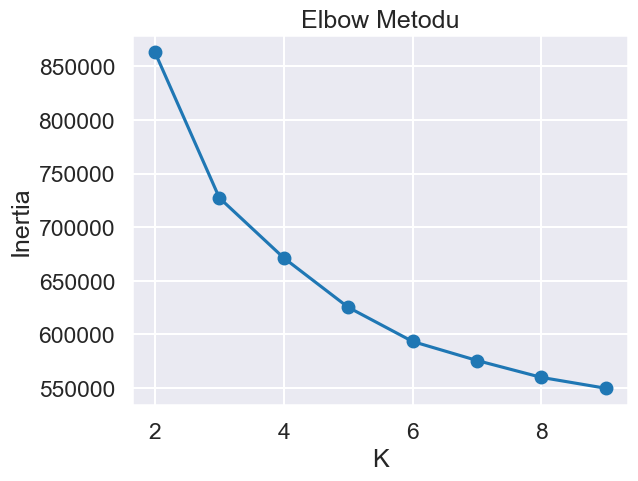

In [247]:
inertia=[]
for k in range(2,10):
    KM=KMeans(n_clusters=k,max_iter=350 ,n_init=10,init='k-means++',algorithm='lloyd',random_state=42)
    KM.fit(x)
    inertia.append(KM.inertia_)

plt.plot(range(2, 10), inertia, marker='o')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.title('Elbow Metodu')
plt.show()

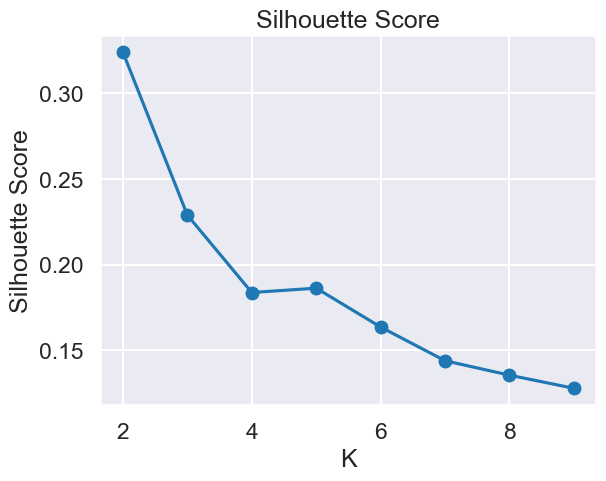

In [248]:
silhouette_scores = []

for k in range(2,10):
    KM = KMeans(n_clusters=k ,random_state=42,max_iter=350 ,n_init=10 , init='k-means++',algorithm='lloyd')
    KM.fit(x)
    score=silhouette_score(x, KM.labels_, sample_size=10000, random_state=42)
    silhouette_scores.append(score)

plt.plot(range(2, 10), silhouette_scores, marker='o')
plt.xlabel('K')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score')
plt.show()

In [249]:
KM = KMeans(n_clusters=5 , max_iter=350,n_init=10 , init='k-means++' , random_state=42 , algorithm='lloyd')
df['cluster'] = KM.fit_predict(x)

In [250]:
df['cluster'].value_counts().sort_values(ascending=False)

cluster
3    18284
2    17963
0    16267
1    11844
4     7642
Name: count, dtype: int64

# Cluster 2 - hər şey yüksək, gecikmə yox → Premium
# Cluster 1 - maaş ən aşağı, balans ən aşağı, gecikmə ən çox → Çox Riskli
# Cluster 4 - riskli amma Cluster 1 qədər deyil
# Cluster 0 və 3 - orta müştərilər

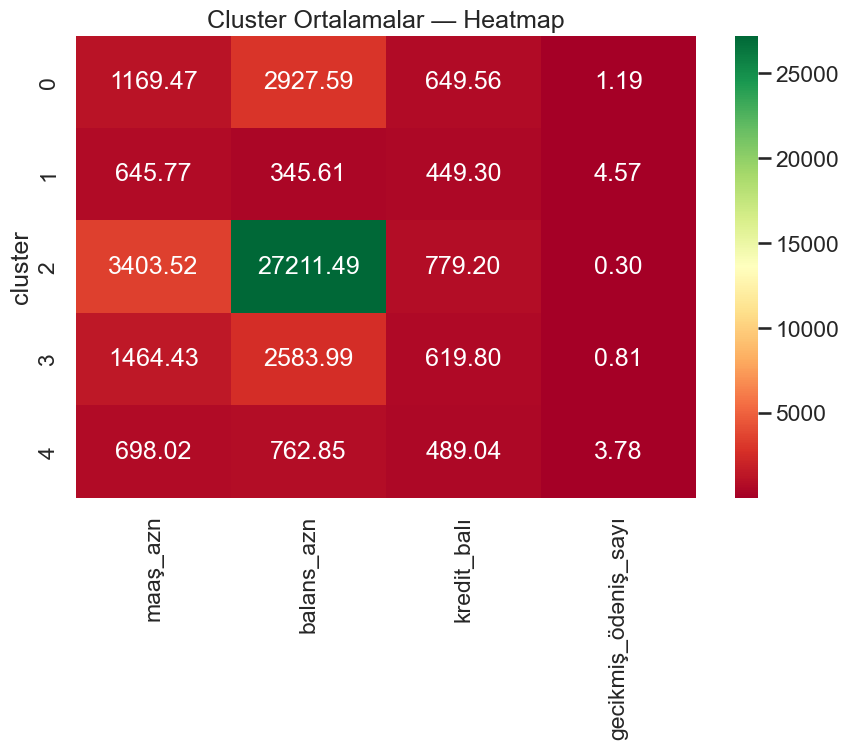

In [251]:
cluster_means = df.groupby('cluster')[['maaş_azn' , 'balans_azn' , 'kredit_balı' , 'gecikmiş_ödəniş_sayı']].mean().round(2)
plt.figure(figsize=(10, 6))
sns.heatmap(cluster_means ,fmt='.2f' , annot=True ,cmap='RdYlGn' )
plt.title('Cluster Ortalamalar — Heatmap')
plt.show()

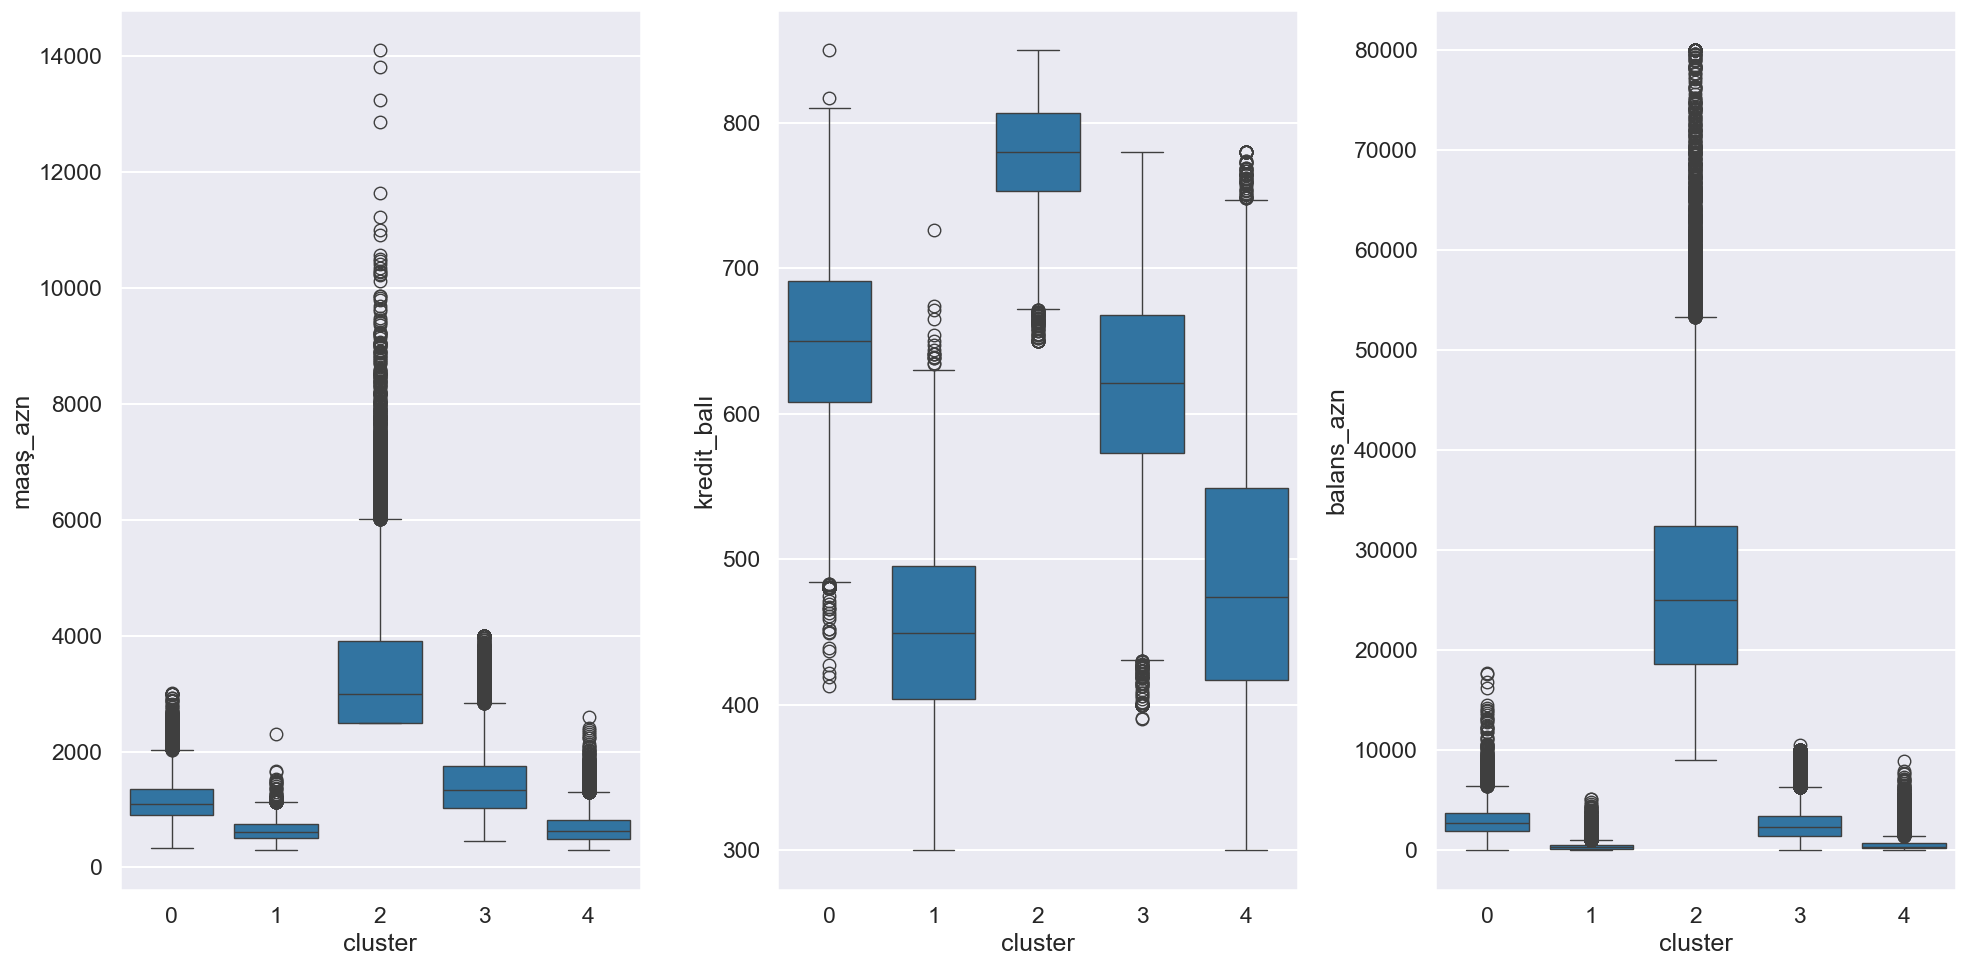

In [252]:
fig , ax = plt.subplots(1,3 , figsize=(20,10))
sns.set_context('talk')
sns.set_style('darkgrid')
sns.boxplot(data=df , x='cluster' , y='maaş_azn' , ax=ax[0])
sns.boxplot(data=df , x='cluster' , y='kredit_balı' , ax=ax[1])
sns.boxplot(data=df , x='cluster' , y='balans_azn' , ax=ax[2])
plt.tight_layout()


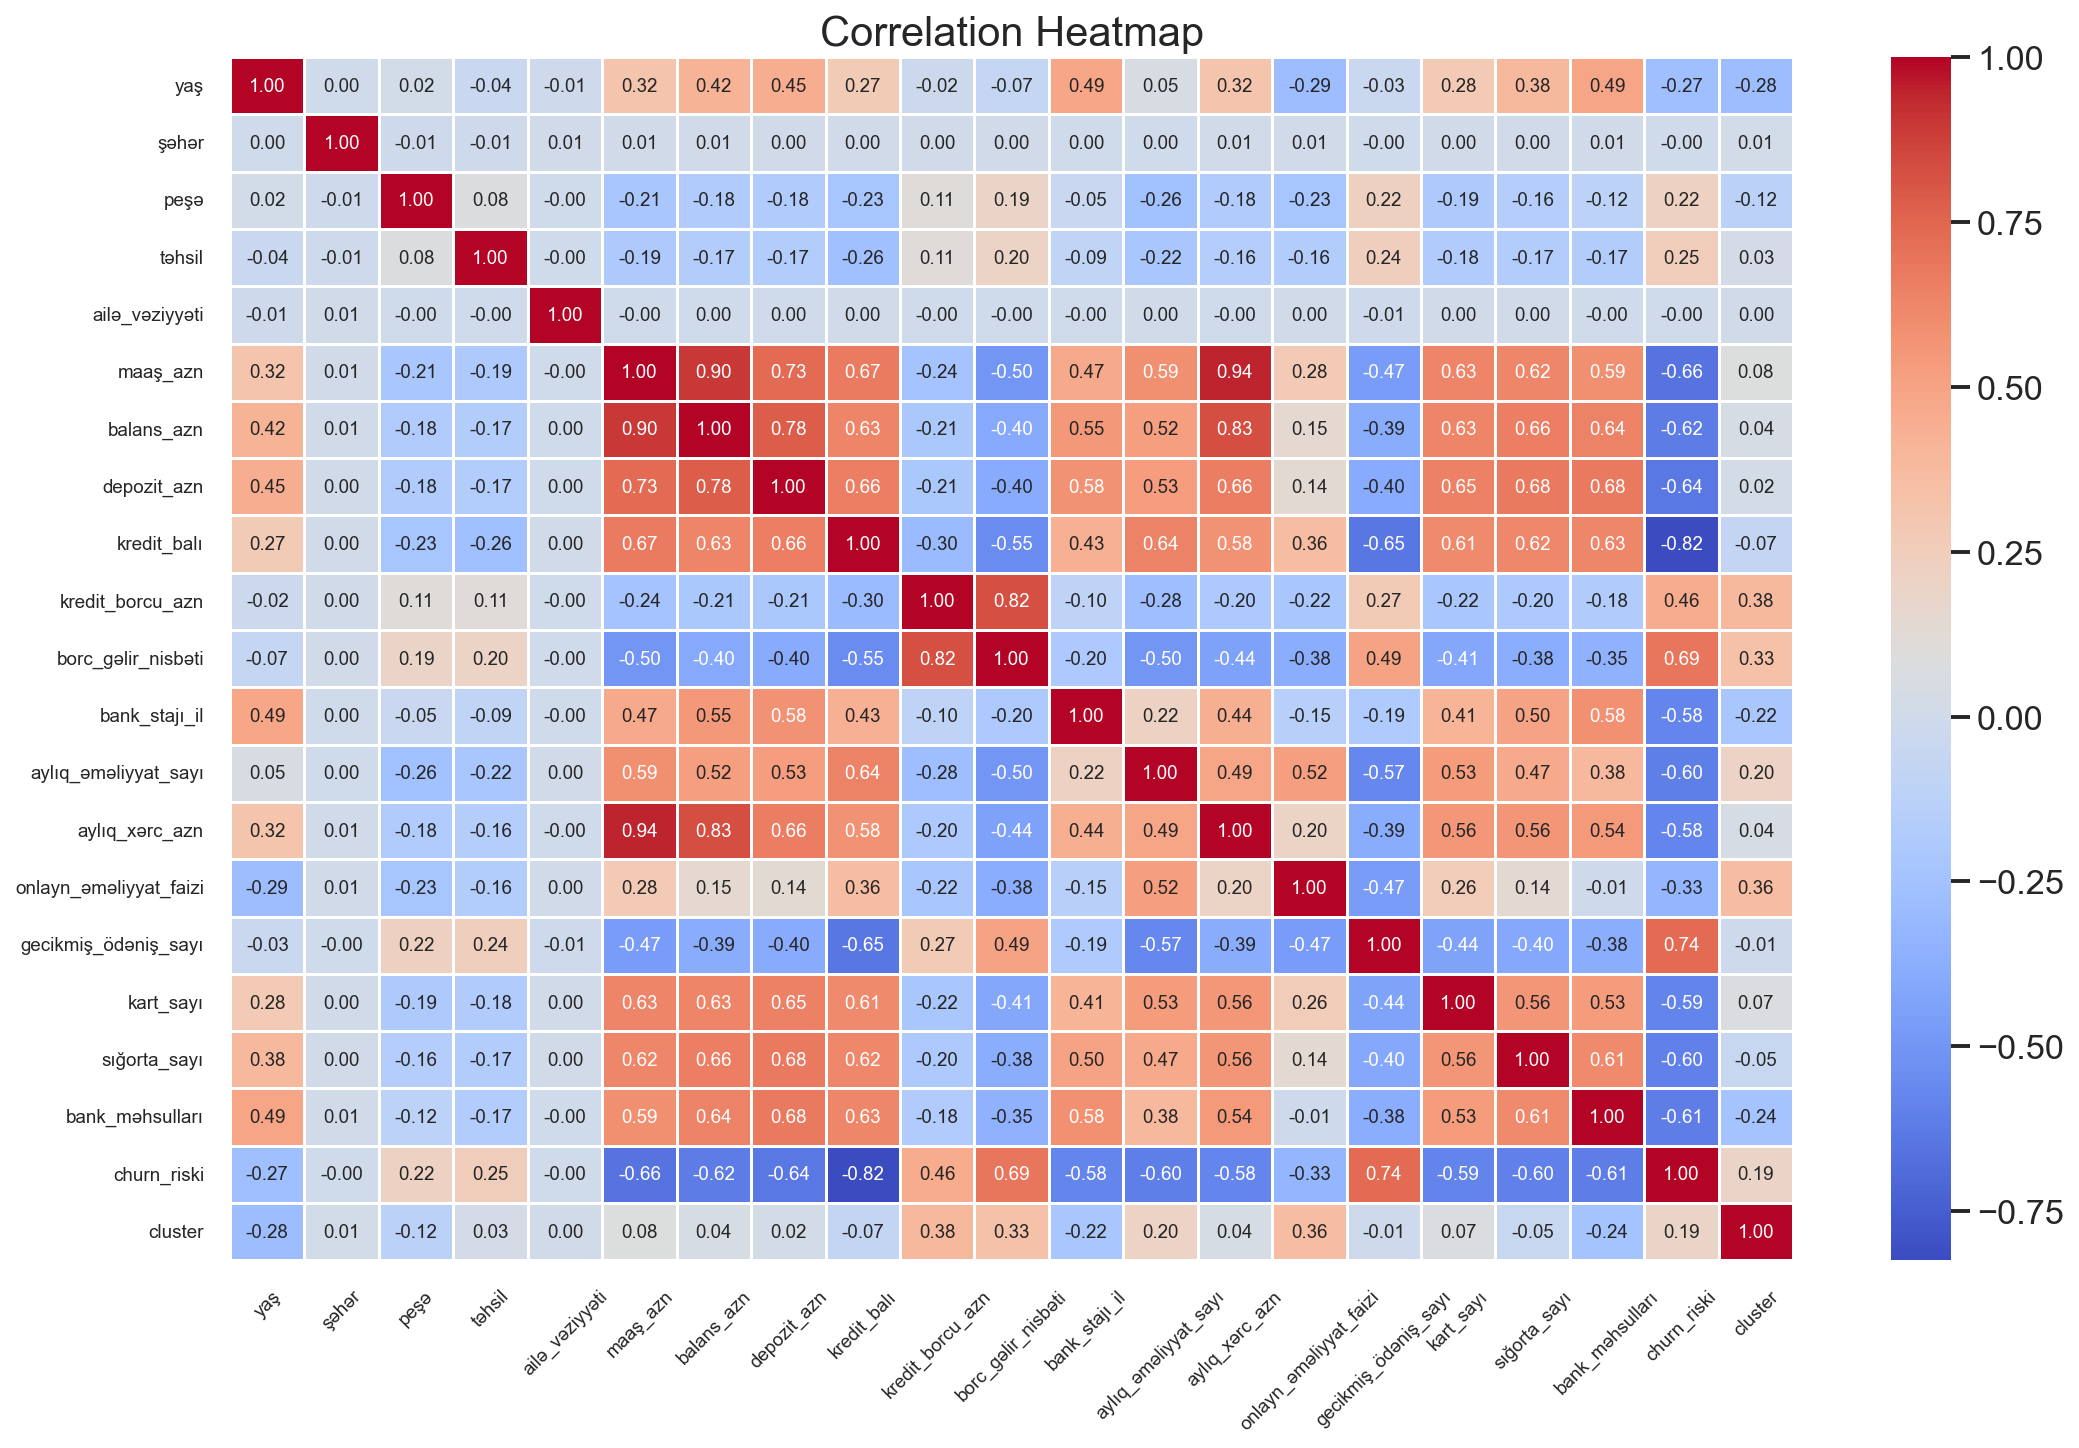

In [253]:
plt.figure(figsize=(15, 10), dpi=150)
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, annot_kws={'size': 9})
plt.title('Correlation Heatmap', fontsize=20)
plt.xticks(fontsize=9, rotation=45)
plt.yticks(fontsize=9, rotation=0)
plt.tight_layout()
plt.show()

PC1 = Maliyyə gücünü göstərir
Sağa getdikcə (2.5 → 10.0) → Cluster 2 → maaş yüksək, balans yüksək, kredit balı yüksək = Premium 
Sola getdikcə (-5.0 → -2.5) → Cluster 1, 4 → maaş aşağı, balans aşağı, borc çox = Riskli

PC2 = Risk səviyyəsini göstərir
Yuxarıda (0 → 2) → Cluster 3 (qırmızı) → orta müştərilər
Aşağıda (-6 → -4) → Cluster 4 (bənövşəyi) → ən riskli müştərilər

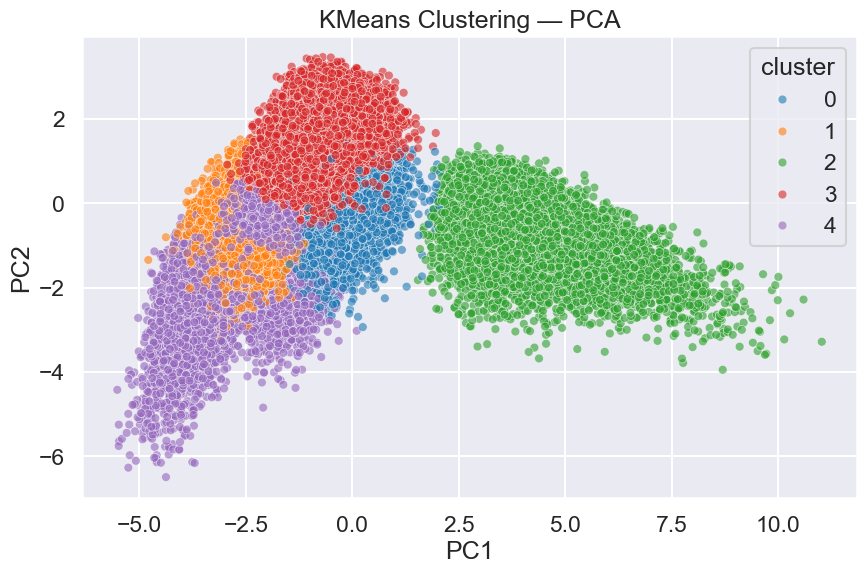

In [254]:
pca = PCA(n_components=2 , random_state=42)
pca_result = pca.fit_transform(x)
plt.figure(figsize=(10,6))
sns.scatterplot(x=pca_result[:,0] , y=pca_result[:,1] , hue=df['cluster'] , palette='tab10' , s=40, alpha=0.6)
plt.title('KMeans Clustering — PCA')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()


In [255]:
df.to_csv('bank_clustered.csv',index=False , encoding='utf-8-sig')

In [256]:
X=df.drop(columns='cluster')
y=df['cluster']
X_train , X_test , y_train,y_test= train_test_split(X,y,train_size=0.8 , stratify=y , random_state=42)

In [257]:
def model_qiymetlendir(model_adi , model , X_test , y_test):
    y_pred = model.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec  = recall_score(y_test, y_pred, average='weighted')
    f1   = f1_score(y_test, y_pred, average='weighted')

    print(f"Model     : {model_adi}")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"\n{classification_report(y_test, y_pred)}")
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.title(f'{model_adi} — Confusion Matrix')
    plt.show()
    return {'accuracy' : acc ,  'precision': prec, 'recall': rec, 'f1': f1}

In [258]:
CT2 = ColumnTransformer([
    ('robust' , RobustScaler() , robust_scale),
    ('standart' , StandardScaler() ,standart_scale)
])
X_train = CT2.fit_transform(X_train)
X_test  = CT2.transform(X_test)

Model     : KNN
Accuracy  : 0.9795
Precision : 0.9795
Recall    : 0.9795
F1 Score  : 0.9794

              precision    recall  f1-score   support

           0       0.97      0.97      0.97      3253
           1       0.97      0.98      0.97      2369
           2       1.00      1.00      1.00      3593
           3       0.98      0.99      0.98      3657
           4       0.97      0.93      0.95      1528

    accuracy                           0.98     14400
   macro avg       0.98      0.97      0.98     14400
weighted avg       0.98      0.98      0.98     14400



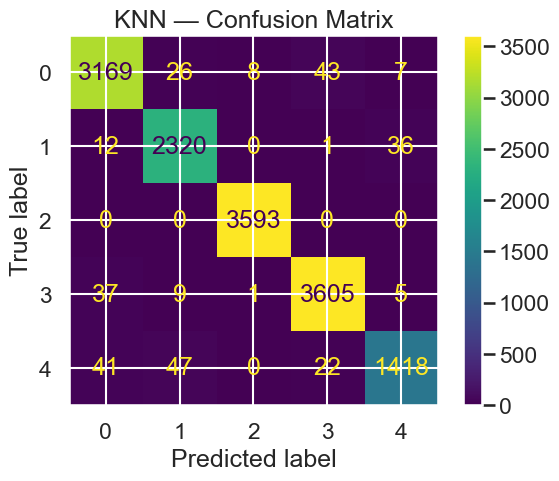

Model     : Logistic Regression (L2)
Accuracy  : 0.9979
Precision : 0.9979
Recall    : 0.9979
F1 Score  : 0.9979

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3253
           1       1.00      1.00      1.00      2369
           2       1.00      1.00      1.00      3593
           3       1.00      1.00      1.00      3657
           4       1.00      1.00      1.00      1528

    accuracy                           1.00     14400
   macro avg       1.00      1.00      1.00     14400
weighted avg       1.00      1.00      1.00     14400



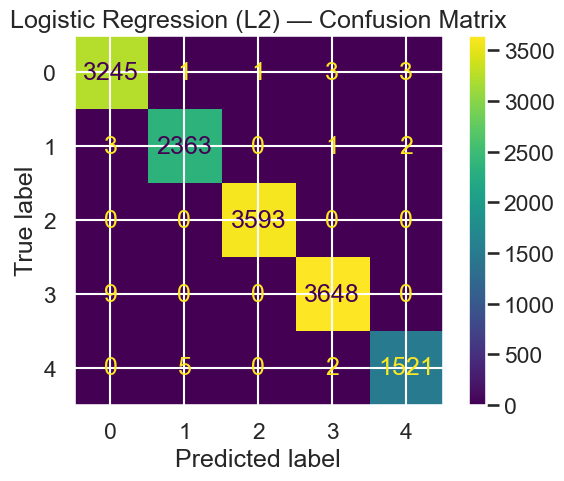

Model     : Logistic Regression (L1)
Accuracy  : 0.9870
Precision : 0.9870
Recall    : 0.9870
F1 Score  : 0.9870

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      3253
           1       0.99      0.98      0.98      2369
           2       1.00      1.00      1.00      3593
           3       0.99      0.99      0.99      3657
           4       0.98      0.98      0.98      1528

    accuracy                           0.99     14400
   macro avg       0.99      0.99      0.99     14400
weighted avg       0.99      0.99      0.99     14400



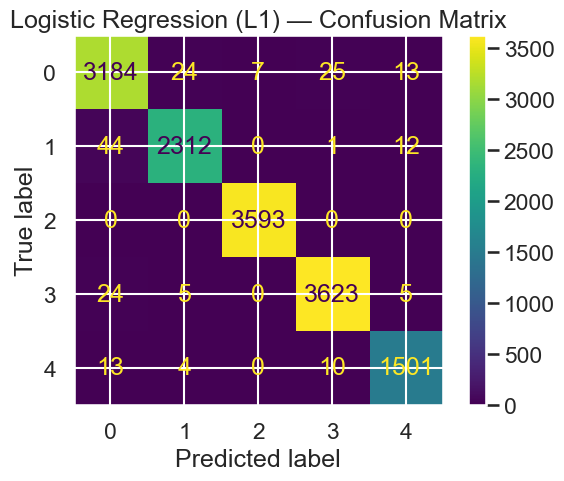

Model     : Decision Tree
Accuracy  : 0.9767
Precision : 0.9768
Recall    : 0.9767
F1 Score  : 0.9767

              precision    recall  f1-score   support

           0       0.95      0.97      0.96      3253
           1       0.97      0.97      0.97      2369
           2       1.00      1.00      1.00      3593
           3       0.98      0.97      0.98      3657
           4       0.97      0.95      0.96      1528

    accuracy                           0.98     14400
   macro avg       0.98      0.97      0.97     14400
weighted avg       0.98      0.98      0.98     14400



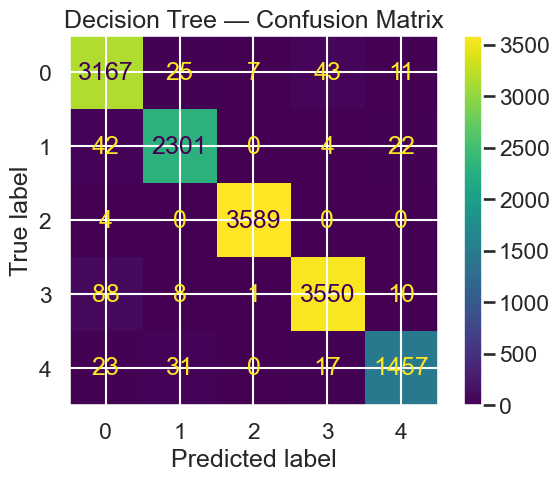

Model     : Random Forest
Accuracy  : 0.9820
Precision : 0.9822
Recall    : 0.9820
F1 Score  : 0.9820

              precision    recall  f1-score   support

           0       0.96      0.98      0.97      3253
           1       0.98      0.98      0.98      2369
           2       1.00      1.00      1.00      3593
           3       0.99      0.97      0.98      3657
           4       0.98      0.97      0.97      1528

    accuracy                           0.98     14400
   macro avg       0.98      0.98      0.98     14400
weighted avg       0.98      0.98      0.98     14400



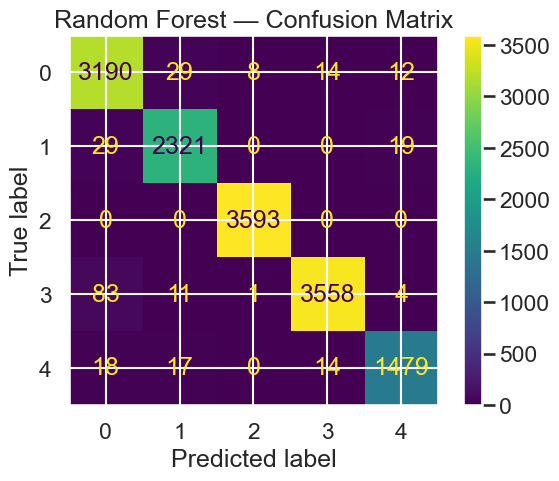

In [259]:
modeller = {
    'KNN': KNeighborsClassifier(),
    'Logistic Regression (L2)': LogisticRegression(penalty='l2', solver='lbfgs', max_iter=1000, random_state=42),
    'Logistic Regression (L1)': LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest': RandomForestClassifier(max_depth=15, random_state=42)
}

result = {}
for ad , model in modeller.items():
    model.fit(X_train , y_train)
    result[ad] = model_qiymetlendir(model_adi=ad, model=model, X_test=X_test, y_test=y_test)


In [260]:
for ad, model in modeller.items():
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc  = accuracy_score(y_test,  model.predict(X_test))
    print(f"{ad}: Train={train_acc:.4f}  Test={test_acc:.4f}")

KNN: Train=0.9858  Test=0.9795
Logistic Regression (L2): Train=0.9982  Test=0.9979
Logistic Regression (L1): Train=0.9854  Test=0.9870
Decision Tree: Train=0.9860  Test=0.9767
Random Forest: Train=0.9935  Test=0.9820


In [261]:
RF = modeller['Random Forest']
importance = pd.Series(RF.feature_importances_, index=X.columns)
importance

yaş                       0.105576
şəhər                     0.137097
peşə                      0.091646
təhsil                    0.066920
ailə_vəziyyəti            0.095465
maaş_azn                  0.041353
balans_azn                0.032062
depozit_azn               0.021015
kredit_balı               0.015629
kredit_borcu_azn          0.038309
borc_gəlir_nisbəti        0.039741
bank_stajı_il             0.000975
aylıq_əməliyyat_sayı      0.010615
aylıq_xərc_azn            0.002163
onlayn_əməliyyat_faizi    0.000620
gecikmiş_ödəniş_sayı      0.060264
kart_sayı                 0.131681
sığorta_sayı              0.002232
bank_məhsulları           0.013923
churn_riski               0.092715
dtype: float64

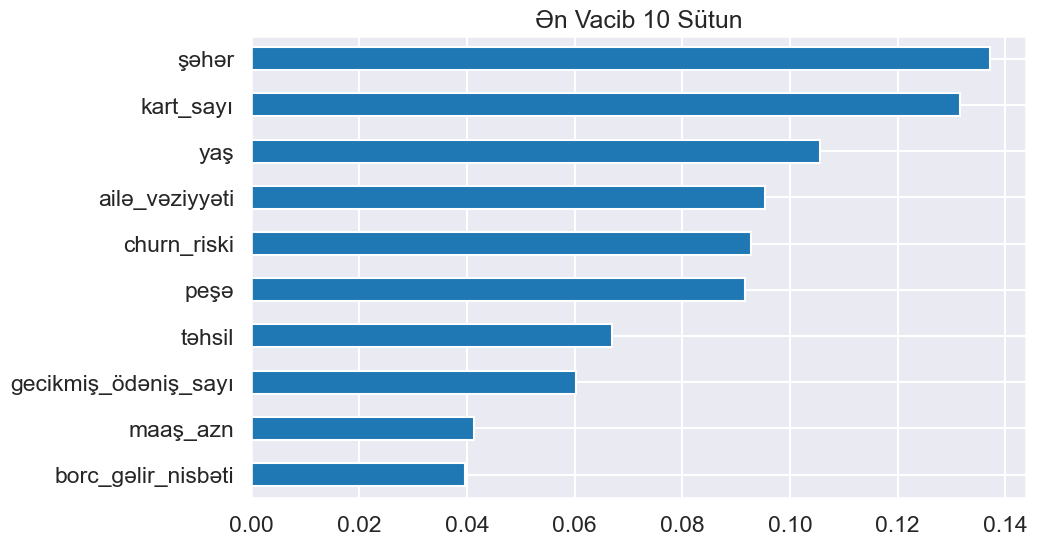

In [262]:
importance.nlargest(10).sort_values(ascending=True).plot(kind='barh',figsize=(10,6))
plt.title('Ən Vacib 10 Sütun')
plt.show()

In [263]:
params = {
    'n_estimators' : [100 ,200 ,300],
    'max_depth' : [10, 15, 20, None],
    'min_samples_split' :[2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'class_weight':[None, 'balanced'],
    'criterion' : ['gini', 'entropy']
}
SKF = StratifiedKFold(n_splits=5 , random_state=42 , shuffle=True)
RSC = RandomizedSearchCV(estimator=RF ,param_distributions=params , cv=SKF , verbose=1 , random_state=42 , n_jobs=-1 , scoring='f1_weighted' , n_iter=60)
RSC.fit(X_train , y_train)

good_params = RSC.best_params_
print(RSC.best_score_)
print(RSC.best_params_)

Fitting 5 folds for each of 60 candidates, totalling 300 fits
0.9830893857864197
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20, 'criterion': 'entropy', 'class_weight': 'balanced'}



Model                            Accuracy         F1    ROC AUC   Log Loss    Brier
KNN                                0.9795     0.9794     0.9969     0.1778   0.0072
Logistic Regression (L2)           0.9979     0.9979     1.0000     0.0121   0.0011
Logistic Regression (L1)           0.9870     0.9870     0.9990     0.0928   0.0089
Decision Tree                      0.9767     0.9767     0.9907     0.2788   0.0085
Random Forest                      0.9820     0.9820     0.9995     0.0573   0.0057
Random Forest (Tuned)              0.9831     0.9831     0.9996     0.0523   0.0052


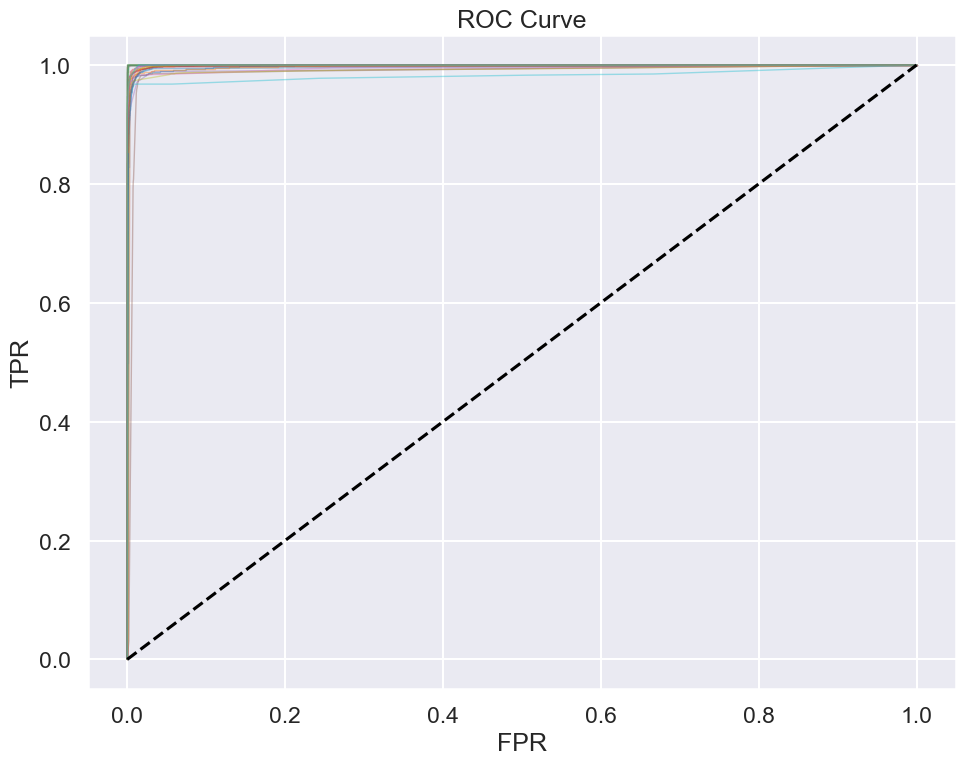

In [264]:
modeller['Random Forest (Tuned)'] = RSC.best_estimator_
y_bin = label_binarize(y_test, classes=[0,1,2,3,4])

print(f"\n{'Model':<30} {'Accuracy':>10} {'F1':>10} {'ROC AUC':>10} {'Log Loss':>10} {'Brier':>8}")

for ad, model in modeller.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)
    acc   = accuracy_score(y_test, y_pred)
    f1    = f1_score(y_test, y_pred, average='weighted')
    roc   = roc_auc_score(y_test, y_prob, multi_class='ovo', average='weighted')
    ll    = log_loss(y_test, y_prob)
    brier = np.mean([brier_score_loss(y_bin[:, i], y_prob[:, i]) for i in range(5)])
    print(f"{ad:<30} {acc:>10.4f} {f1:>10.4f} {roc:>10.4f} {ll:>10.4f} {brier:>8.4f}")

plt.figure(figsize=(10, 8))
for ad, model in modeller.items():
    y_prob = model.predict_proba(X_test)
    for i in range(5):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
        plt.plot(fpr, tpr, lw=1, alpha=0.4)
plt.plot([0,1],[0,1],'k--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC Curve')
plt.tight_layout()
plt.show()

Model     : Random Forest
Accuracy  : 0.9831
Precision : 0.9832
Recall    : 0.9831
F1 Score  : 0.9831

              precision    recall  f1-score   support

           0       0.96      0.98      0.97      3253
           1       0.98      0.98      0.98      2369
           2       1.00      1.00      1.00      3593
           3       0.99      0.97      0.98      3657
           4       0.98      0.97      0.98      1528

    accuracy                           0.98     14400
   macro avg       0.98      0.98      0.98     14400
weighted avg       0.98      0.98      0.98     14400



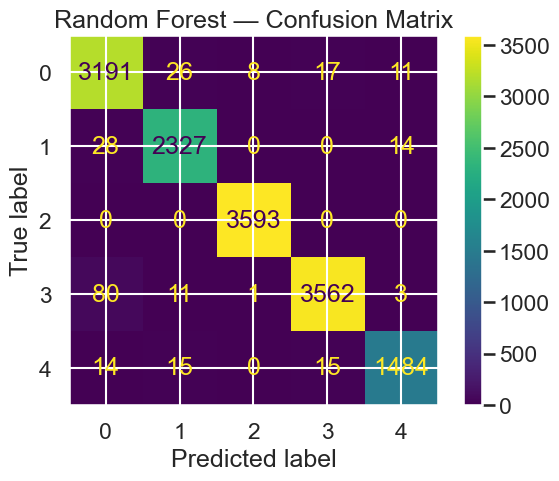

{'accuracy': 0.983125,
 'precision': 0.9832356467617223,
 'recall': 0.983125,
 'f1': 0.9831391751218732}

In [265]:
model_qiymetlendir(model_adi='Random Forest' , model=RSC.best_estimator_ , X_test=X_test , y_test=y_test)

In [266]:
yeni_musteri = pd.DataFrame([{
    'yaş'                    : 35,
    'şəhər'                  : 0,  
    'peşə'                   : 3,
    'təhsil'                 : 2,
    'ailə_vəziyyəti'         : 1,
    'maaş_azn'               : 2500,
    'balans_azn'             : 15000,
    'depozit_azn'            : 3000,
    'kredit_balı'            : 720,
    'kredit_borcu_azn'       : 5000,
    'borc_gəlir_nisbəti'     : 16.7,
    'bank_stajı_il'          : 8,
    'aylıq_əməliyyat_sayı'   : 35,
    'aylıq_xərc_azn'         : 1200,
    'onlayn_əməliyyat_faizi' : 75.0,
    'gecikmiş_ödəniş_sayı'   : 0,
    'kart_sayı'              : 2,
    'sığorta_sayı'           : 1,
    'bank_məhsulları'        : 2,
    'churn_riski'            : 0.15
}])
yeni_scaled = CT2.transform(yeni_musteri)
proqnoz = RSC.best_estimator_.predict(yeni_scaled)[0]
cluster_adlari = {
    0: 'Gənc/Digital Müştəri',
    1: 'Çox Riskli Müştəri',
    2: 'Premium Müştəri',
    3: 'Orta Müştəri',
    4: 'Riskli Müştəri'
}
print(f'Proqnoz: {cluster_adlari[proqnoz]}')

Proqnoz: Orta Müştəri


In [267]:
pickle.dump(RSC.best_estimator_ ,open('model.pkl' , 'wb'))
pickle.dump(CT2 , open('scaler.pkl' , 'wb'))